---
date: "2026-08-31"
date-modified: last-modified
format:
  html:
    toc: true
---



# Power-Law Distributions, Heavy Tails, and Zipf's Law in Recommendation Corpora

In large-scale digital systems—including video platforms, search engines, and social networks—user activity, item views, and keyword frequencies do not follow Gaussian or exponential distributions. Instead, they exhibit **heavy-tailed, scale-invariant power-law distributions** characterized by **Zipf's Law** and the **Pareto Principle** ($80/20$ rule).

A small fraction of head items receives billions of impressions, while millions of long-tail items receive sparse interactions. This massive distributional skew introduces severe **sampling bias** when training neural retrieval models on in-batch streaming data.

This note develops the mathematical foundations of continuous and discrete power-law distributions, proves conditions under which moments diverge to infinity, derives the Maximum Likelihood Estimator (Hill Estimator), and formalizes the catalog exposure dilemma in recommender systems.

---

## 1\. Continuous Power-Law Distributions: Mathematical Formulation

::: {#def-power-law}
## Continuous Power-Law (Pareto) Distribution
Let $X$ be a positive continuous [random variable](random-variables.ipynb). $X$ follows a power-law distribution with exponent $\alpha > 1$ and minimum support threshold $x_{\min} > 0$ if its [probability density function](probability-density-function.ipynb) is given by:

$$
p(x) = \frac{\alpha - 1}{x_{\min}} \left( \frac{x}{x_{\min}} \right)^{-\alpha} \quad \text{for } x \ge x_{\min}
$$

The [cumulative distribution function](cumulative-distribution-functions.ipynb) $F(x) = P(X \le x)$ and complementary cumulative distribution function (survival function) $S(x) = P(X > x)$ are:

$$
\begin{aligned}
F(x) &= 1 - \left( \frac{x}{x_{\min}} \right)^{-(\alpha - 1)} \quad \text{for } x \ge x_{\min} \\
S(x) &\equiv P(X > x) = \left( \frac{x}{x_{\min}} \right)^{-(\alpha - 1)}
\end{aligned}
$$
:::

### 1.1\. The Scale-Invariance Property

A defining characteristic of power-law phenomena is **scale invariance**: multiplying the scale of observation by a constant factor $c > 0$ preserves the relative shape of the distribution.

::: {#prp-scale-invariance}
## Scale Invariance of Power Laws
For any scaling constant $c > 1$ and any threshold $x \ge x_{\min}$:

$$
P(X > c x \mid X > x) = \frac{P(X > c x)}{P(X > x)} = \frac{(c x / x_{\min})^{-(\alpha - 1)}}{(x / x_{\min})^{-(\alpha - 1)}} = c^{-(\alpha - 1)}
$$

The conditional survival probability depends strictly on the relative ratio $c$, completely independent of the baseline scale $x$.
:::



## 2\. Moments and Heavy-Tail Divergence

Unlike Gaussian distributions where all polynomial moments exist, power-law distributions possess finite moments only up to order $k < \alpha - 1$.

::: {#thm-power-law-moments}
## Raw Moments of the Power-Law Distribution
The $k$-th raw [moment](expectation.ipynb) $\mathbb{E}[X^k]$ exists if and only if $\alpha > k + 1$, in which case:

$$
\mathbb{E}[X^k] = \int_{x_{\min}}^\infty x^k p(x) dx = \frac{\alpha - 1}{\alpha - 1 - k} x_{\min}^k
$$

Specifically:

1. **Mean ($\mathbb{E}[X]$):**
   $$
   \mathbb{E}[X] = \begin{cases} \frac{\alpha - 1}{\alpha - 2} x_{\min} & \text{if } \alpha > 2 \\ +\infty & \text{if } 1 < \alpha \le 2 \end{cases}
   $$
2. **Variance ($\text{Var}(X)$):**
   $$
   \text{Var}(X) = \begin{cases} \frac{(\alpha - 1) x_{\min}^2}{(\alpha - 2)^2 (\alpha - 3)} & \text{if } \alpha > 3 \\ +\infty & \text{if } 1 < \alpha \le 3 \end{cases}
   $$
:::

::: {.callout-tip collapse="true"}
## Proof of Moment Formula
Evaluating the definite integral for $k \ge 1$:
$$
\mathbb{E}[X^k] = \int_{x_{\min}}^\infty x^k \frac{\alpha - 1}{x_{\min}} \left( \frac{x}{x_{\min}} \right)^{-\alpha} dx = (\alpha - 1) x_{\min}^{\alpha - 1} \int_{x_{\min}}^\infty x^{k - \alpha} dx
$$
The antiderivative is:
$$
\int x^{k - \alpha} dx = \frac{x^{k - \alpha + 1}}{k - \alpha + 1}
$$
Evaluating the limit at upper bound $\infty$:
* If $k - \alpha + 1 \ge 0 \iff \alpha \le k + 1$, the integral diverges to $+\infty$.
* If $k - \alpha + 1 < 0 \iff \alpha > k + 1$, the upper limit vanishes, yielding:
$$
\mathbb{E}[X^k] = (\alpha - 1) x_{\min}^{\alpha - 1} \left[ 0 - \frac{x_{\min}^{k - \alpha + 1}}{k - \alpha + 1} \right] = \frac{\alpha - 1}{\alpha - 1 - k} x_{\min}^k
$$
For the variance:
$$
\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{\alpha - 1}{\alpha - 3} x_{\min}^2 - \left( \frac{\alpha - 1}{\alpha - 2} x_{\min} \right)^2 = \frac{(\alpha - 1) x_{\min}^2}{(\alpha - 2)^2 (\alpha - 3)}
$$
which requires $\alpha > 3$ for finite variance. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Infinite Variance in Practice
In internet traffic and recommender platforms, empirical estimates of $\alpha$ often fall in the interval $[1.5, 2.5]$. In this regime, the theoretical variance is infinite. Sample averages $\bar{X}_N$ do not concentrate at the standard $\mathcal{O}(1/\sqrt{N})$ Central Limit Theorem rate, and occasional "black swan" extreme items dominate aggregated empirical sums.
:::



## 3\. Discrete Power Laws & Zipf's Law

When ranking a discrete catalogue of $M$ items by descending popularity $j \in \{1, 2, \dots, M\}$:

::: {#def-zipf}
## Zipf's Law
The probability $q_j$ that a randomly chosen interaction involves the item of rank $j$ is given by:

$$
q_j = \frac{j^{-\gamma}}{H_{M, \gamma}} \quad \text{where } H_{M, \gamma} = \sum_{k=1}^M k^{-\gamma}
$$

where $\gamma \approx 1$ is the Zipf scaling parameter and $H_{M, \gamma}$ is the generalized harmonic number. As $M \to \infty$ for $\gamma > 1$, $H_{M, \gamma} \to \zeta(\gamma)$, the Riemann zeta function.
:::

---

## 4\. Maximum Likelihood Estimation: The Hill Estimator

Given an empirical dataset of $N$ independent observations $x_1, x_2, \dots, x_N \ge x_{\min}$, we estimate the unknown power-law exponent $\alpha$ via [Maximum Likelihood Estimation](maximum-likelihood-estimation.ipynb).

::: {#thm-hill-estimator}
## Maximum Likelihood Estimator (Hill Estimator)
The maximum likelihood estimator $\hat{\alpha}$ for the power-law exponent $\alpha$ is:

$$
\hat{\alpha} = 1 + N \left[ \sum_{i=1}^N \ln\left( \frac{x_i}{x_{\min}} \right) \right]^{-1}
$$

with Fisher Information $I(\alpha) = \frac{N}{(\alpha - 1)^2}$ and asymptotic variance $\text{Var}(\hat{\alpha}) = \frac{(\alpha - 1)^2}{N}$.
:::

::: {.callout-tip collapse="true"}
## Proof of Hill Estimator
The likelihood function for $N$ i.i.d. observations is:
$$
L(\alpha) = \prod_{i=1}^N \frac{\alpha - 1}{x_{\min}} \left( \frac{x_i}{x_{\min}} \right)^{-\alpha} = (\alpha - 1)^N x_{\min}^{N(\alpha - 1)} \prod_{i=1}^N x_i^{-\alpha}
$$
Taking the natural logarithm yields the log-likelihood:
$$
\ell(\alpha) = \ln L(\alpha) = N \ln(\alpha - 1) + N(\alpha - 1)\ln x_{\min} - \alpha \sum_{i=1}^N \ln x_i
$$
Differentiating with respect to $\alpha$ and setting to zero:
$$
\frac{\partial \ell}{\partial \alpha} = \frac{N}{\alpha - 1} + N \ln x_{\min} - \sum_{i=1}^N \ln x_i = \frac{N}{\alpha - 1} - \sum_{i=1}^N \ln\left( \frac{x_i}{x_{\min}} \right) = 0
$$
Solving for $\alpha$ gives:
$$
\hat{\alpha} = 1 + \frac{N}{\sum_{i=1}^N \ln(x_i / x_{\min})}
$$
The second derivative is:
$$
\frac{\partial^2 \ell}{\partial \alpha^2} = -\frac{N}{(\alpha - 1)^2} < 0
$$
The Fisher Information is $I(\alpha) = -\mathbb{E}\left[ \frac{\partial^2 \ell}{\partial \alpha^2} \right] = \frac{N}{(\alpha - 1)^2}$, proving asymptotic variance $\text{Var}(\hat{\alpha}) = \frac{(\alpha - 1)^2}{N}$. $\blacksquare$
:::



## 5\. The Power-Law Dilemma in In-Batch Neural Retrieval

In modern two-tower retrieval models, training batches of size $B$ are formed by sampling positive interactions $\{(x_i, y_i)\}_{i=1}^B$ from live user activity streams.

Since streaming interactions follow the Zipfian distribution $q_j \propto j^{-\gamma}$, the probability that item $j$ appears at least once in a mini-batch of size $B$ is:

$$
p_j = 1 - (1 - q_j)^B \approx B q_j \quad (\text{for } q_j \ll 1)
$$

### The Resulting Sampling Bias:
1. **Head Items (Top $1\%$):** Appear in virtually every mini-batch ($p_{\text{head}} \approx 1.0$). They act as negative candidates for almost all queries in the batch!
2. **Tail Items ($90\%$ of catalog):** Rarely sampled into any batch ($p_{\text{tail}} \approx 0.0001$).

If in-batch softmax is computed naively without frequency correction, **popular head items are excessively penalized**, causing the retrieval model to under-recommend relevant head items and over-recommend obscure tail content. This establishes the critical necessity for **sampling-bias correction**.



## 6\. PyTorch Implementation: Power-Law Sampling & MLE Fitting

We simulate power-law and Zipfian streaming data in PyTorch:
1. Generating continuous power-law samples via **Inverse Transform Sampling**:
   $$
   U \sim \text{Uniform}(0, 1) \implies X = x_{\min} (1 - U)^{-\frac{1}{\alpha - 1}}
   $$
2. Log-log visualization of the linear CCDF signature.
3. Verification of the Hill Maximum Likelihood Estimator.


Executing Power-Law simulations on: cuda
True Exponent alpha: 2.5000
Hill MLE alpha:      2.4983 +/- 0.0131 (95% CI)


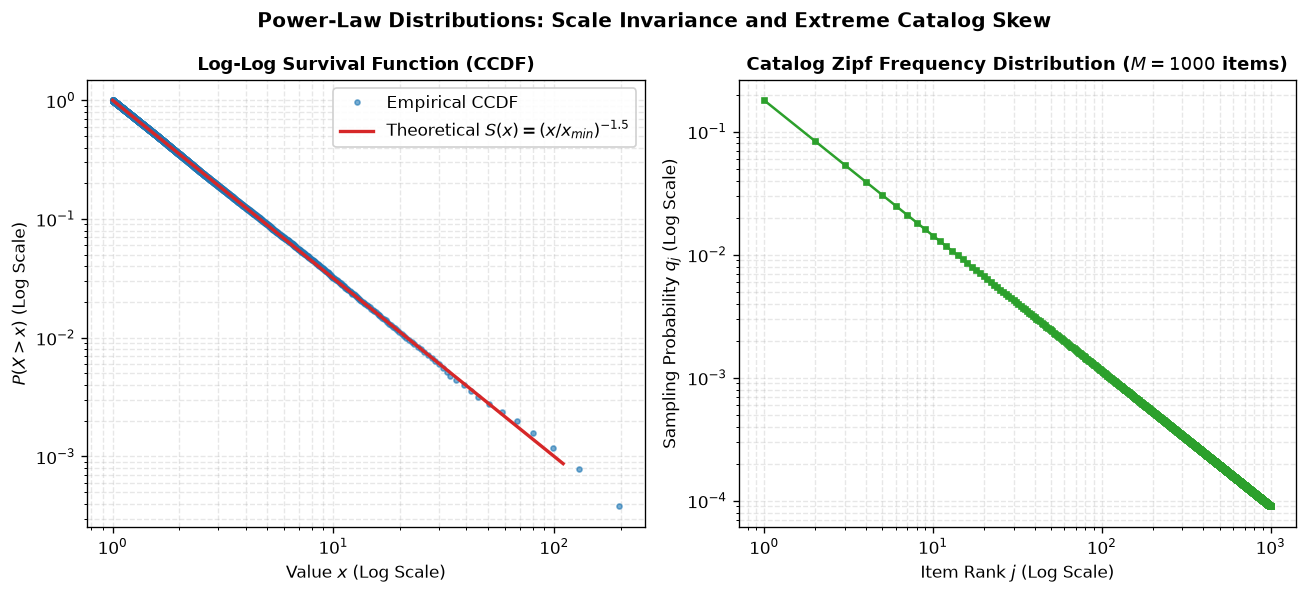

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Power-Law simulations on: {device}")

# Generate Power-Law samples via Inverse Transform Sampling
def sample_power_law(N, alpha=2.5, x_min=1.0):
    u = torch.rand(N, device=device)
    # Inverse CDF: X = x_min * (1 - U)^(-1 / (alpha - 1))
    x = x_min * (1.0 - u)**(-1.0 / (alpha - 1.0))
    return x

# Parameter Setup
true_alpha = 2.5
x_min = 1.0
N_samples = 50000

torch.manual_seed(42)
samples = sample_power_law(N_samples, alpha=true_alpha, x_min=x_min)

# Compute Hill Maximum Likelihood Estimator
log_ratios = torch.log(samples / x_min)
alpha_mle = (1.0 + N_samples / torch.sum(log_ratios)).item()
se_mle = (alpha_mle - 1.0) / np.sqrt(N_samples)

print(f"True Exponent alpha: {true_alpha:.4f}")
print(f"Hill MLE alpha:      {alpha_mle:.4f} +/- {1.96 * se_mle:.4f} (95% CI)")

# Empirical Survival Function (CCDF) on CPU for plotting
samples_np = np.sort(samples.cpu().numpy())
ccdf_empirical = 1.0 - np.arange(1, N_samples + 1) / N_samples

# Filter non-zero values for log-log plot
valid_idx = ccdf_empirical > 0
x_vals = samples_np[valid_idx]
y_vals = ccdf_empirical[valid_idx]

# Theoretical CCDF
x_theory = np.linspace(x_min, np.percentile(samples_np, 99.9), 1000)
y_theory = (x_theory / x_min)**(-(true_alpha - 1.0))

# Visualizations
plt.figure(figsize=(11, 5), dpi=120)

# Log-Log CCDF Plot (Linear signature of power laws)
plt.subplot(1, 2, 1)
plt.loglog(x_vals[::20], y_vals[::20], 'o', label='Empirical CCDF', color='#1f77b4', markersize=3, alpha=0.6)
plt.loglog(x_theory, y_theory, label=rf'Theoretical $S(x) = (x/x_{{min}})^{{-{true_alpha - 1.0}}}$', color='#d62728', lw=2)
plt.title('Log-Log Survival Function (CCDF)', fontsize=11, fontweight='bold')
plt.xlabel('Value $x$ (Log Scale)', fontsize=10)
plt.ylabel('$P(X > x)$ (Log Scale)', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)

# Rank-Frequency Plot (Zipf Law on Catalog)
M_items = 1000
ranks = np.arange(1, M_items + 1)
zipf_probs = (1.0 / ranks**1.1) / np.sum(1.0 / ranks**1.1)

plt.subplot(1, 2, 2)
plt.loglog(ranks, zipf_probs, 's-', color='#2ca02c', lw=1.5, markersize=3)
plt.title(f'Catalog Zipf Frequency Distribution ($M = {M_items}$ items)', fontsize=11, fontweight='bold')
plt.xlabel('Item Rank $j$ (Log Scale)', fontsize=10)
plt.ylabel('Sampling Probability $q_j$ (Log Scale)', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.suptitle('Power-Law Distributions: Scale Invariance and Extreme Catalog Skew', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---

> **References & Acknowledgments:**
> 
> * Newman, Mark E.J. "Power laws, Pareto distributions and Zipf's law." *Contemporary Physics* 46.5 (2005): 323-351.
> * Clauset, Aaron, Cosma Rohilla Shalizi, and Mark E.J. Newman. "Power-law distributions in empirical data." *SIAM Review* 51.4 (2009): 661-703.
> * Hill, Bruce M. "A simple general approach to inference about the tail of a distribution." *The Annals of Statistics* (1975): 1163-1174.
